In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:

# ----------------------------------------------------------------------
# Section 1: Data Retrieval
# ----------------------------------------------------------------------

excel_file = 'TOP 500 statistics.xlsx'

# Definition new column names for the datasets
country_headers = ['Rank', 'Country', 'Count', 'System Share (%)', 'Rmax (GFlops)', 'Rpeak (GFlops)', 'Cores']
app_headers = ['Application Area', 'Count', 'System Share (%)', 'Rmax (GFlops)', 'Rpeak (GFlops)', 'Cores']
seg_headers = ['Segment', 'Count', 'System Share (%)', 'Rmax (GFlops)', 'Rpeak (GFlops)', 'Cores']


# Countries and regions

df_cr_june_2025 = pd.read_excel(excel_file, sheet_name='Countries and regions June 2025', header=None, skiprows=1, names=country_headers, dtype=str)
df_cr_june_2020 = pd.read_excel(excel_file, sheet_name='Countries and regions June 2020', header=None, skiprows=1, names=country_headers, dtype=str)

print("Countries and regions June 2025:")
print(df_cr_june_2025.head())

print("\nCountries and regions June 2020:")
print(df_cr_june_2020.head())

# Application Area
df_app_june_2025 = pd.read_excel(excel_file, sheet_name='Application area June 2025', header=None, skiprows=1, names=app_headers, dtype=str)
df_app_june_2020 = pd.read_excel(excel_file, sheet_name='Application area June 2020', header=None, skiprows=1, names=app_headers, dtype=str)

print("\nApplication Area June 2025:")
print(df_app_june_2025.head())

print("\nApplication Area June 2020:")
print(df_app_june_2020.head())

# Segments
df_seg_june_2025 = pd.read_excel(excel_file, sheet_name='Segments June 2025', header=None, skiprows=1, names=seg_headers, dtype=str)
df_seg_june_2020 = pd.read_excel(excel_file, sheet_name='Segments June 2020', header=None, skiprows=1, names=seg_headers, dtype=str)

print("\nSegments June 2025:")
print(df_seg_june_2025.head())

print("\nSegments June 2020:")
print(df_seg_june_2020.head())



Countries and regions June 2025:
  Rank        Country Count     System Share (%) Rmax (GFlops) Rpeak (GFlops)  \
0    1  United States   175                   35    6698604970    10642950168   
1    2          China    47  2025-04-09 00:00:00     281269604      471807345   
2    3        Germany    41  2025-02-08 00:00:00    1185266660     1519298880   
3    4          Japan    39  2025-08-07 00:00:00    1229009840     1631301398   
4    5         France    25                    5     327543500      508630042   

        Cores  
0  58,129,200  
1  18,920,568  
2   8,943,756  
3  12,787,024  
4   4,676,480  

Countries and regions June 2020:
  Rank        Country Count     System Share (%) Rmax (GFlops) Rpeak (GFlops)  \
0    1          China   226                 45.2     565553102     1186992367   
1    2  United States   113  2025-06-22 00:00:00     621655590      884317444   
2    3          Japan    29  2025-08-05 00:00:00     527607512      691558660   
3    4         France    1


Analyzing Countries and Regions Data



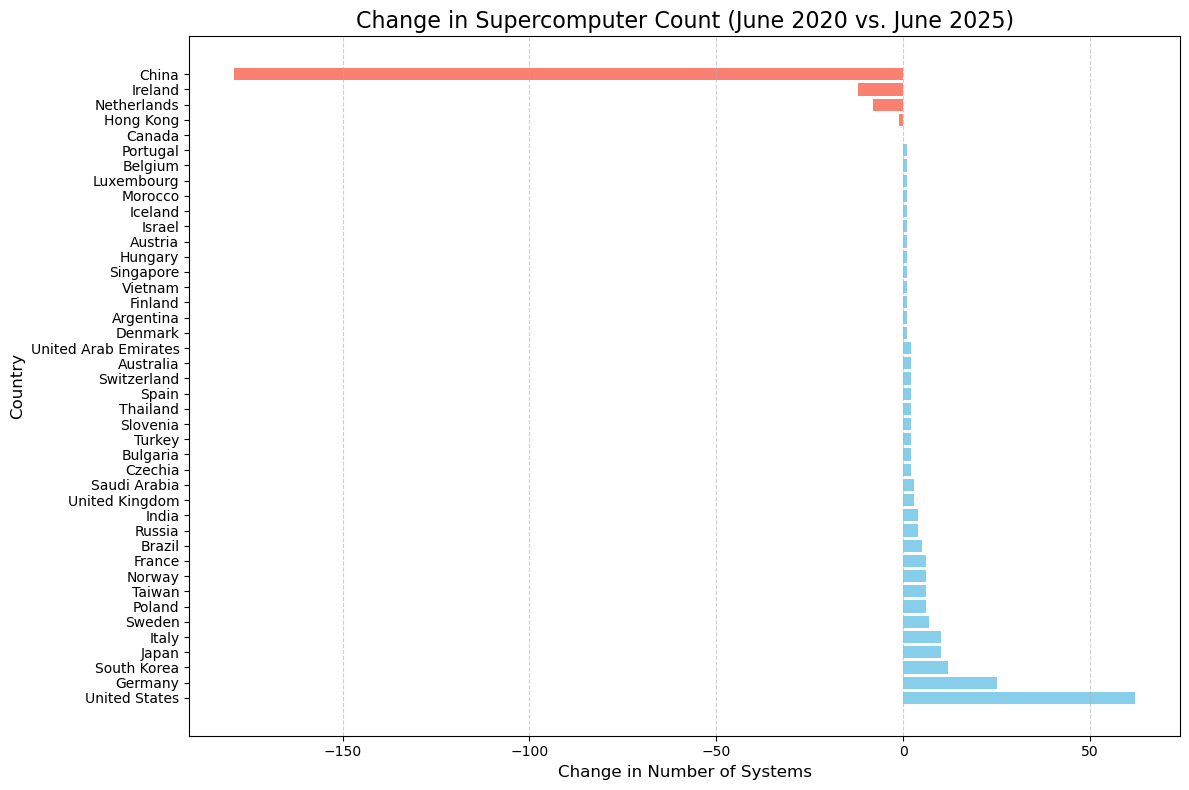

In [3]:
# ----------------------------------------------------------------------
# Section 2: Comprehensive Data Analysis and Visualization
# ----------------------------------------------------------------------

# --- Analysis for Countries and Regions ---
print("\n" + "="*50)
print("Analyzing Countries and Regions Data")
print("="*50 + "\n")


for df in [df_cr_june_2025, df_cr_june_2020]:
    for col in ['Count', 'Rmax (GFlops)']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)


df_cr_june_2025['Country'] = df_cr_june_2025['Country'].str.strip()
df_cr_june_2020['Country'] = df_cr_june_2020['Country'].str.strip()


merged_cr = pd.merge(df_cr_june_2025, df_cr_june_2020, on='Country', how='outer', suffixes=('_2025', '_2020')).fillna(0)
merged_cr['Count_Change'] = merged_cr['Count_2025'] - merged_cr['Count_2020']
# merged_cr['Rmax_Change'] = merged_cr['Rmax (GFlops)_2025'] - merged_cr['Rmax (GFlops)_2020']

# Plot 1: Change in System Count by Country
plot_cr_count = merged_cr.sort_values(by='Count_Change', ascending=False)
plt.figure(figsize=(12, 8))
plt.barh(plot_cr_count['Country'], plot_cr_count['Count_Change'], color=['skyblue' if c > 0 else 'salmon' for c in plot_cr_count['Count_Change']])
plt.title('Change in Supercomputer Count (June 2020 vs. June 2025)', fontsize=16)
plt.xlabel('Change in Number of Systems', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

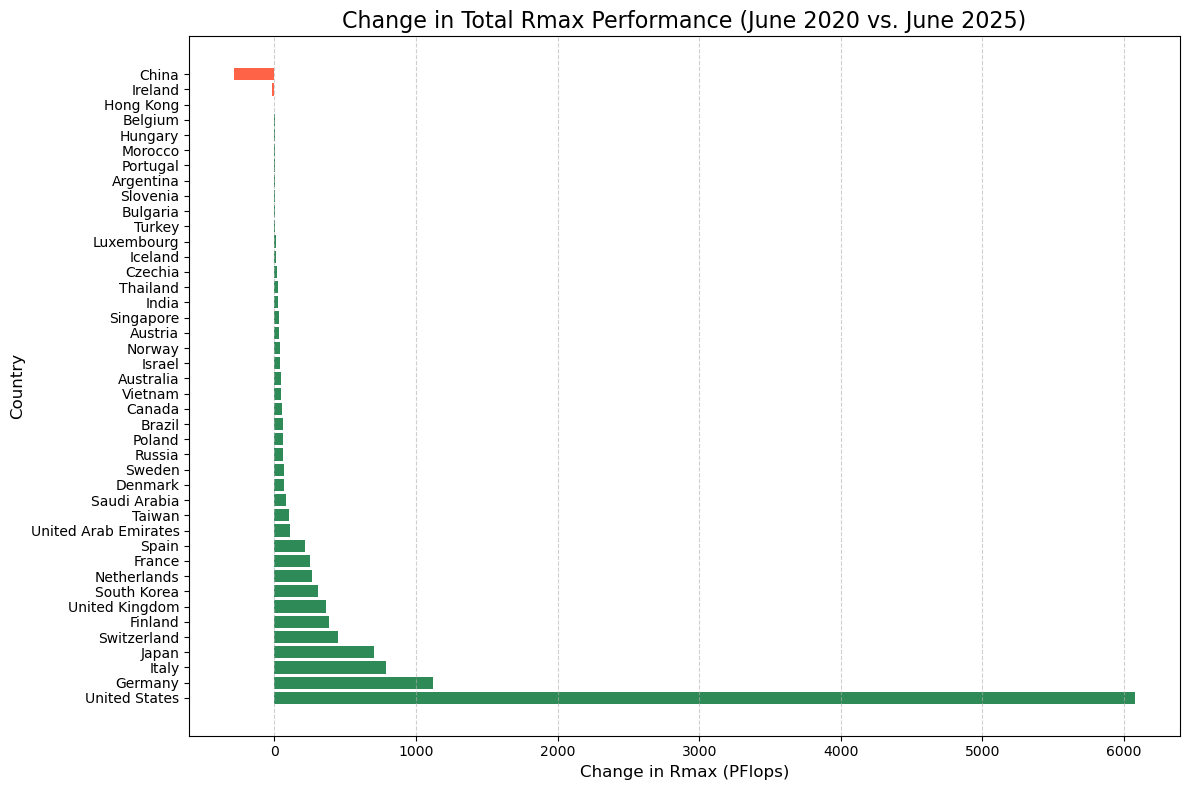

In [4]:
# for df in [df_cr_june_2025, df_cr_june_2020]:
#     df['Rmax (GFlops)'] = pd.to_numeric(df['Rmax (GFlops)'], errors='coerce').fillna(0)
        
merged_cr['Rmax_Change'] = merged_cr['Rmax (GFlops)_2025'] - merged_cr['Rmax (GFlops)_2020']

# Plot 2: Change in Rmax Performance (PetaFlops)

plot_cr_rmax = merged_cr.sort_values(by='Rmax_Change', ascending=False)
plt.figure(figsize=(12, 8))
plt.barh(plot_cr_rmax['Country'], plot_cr_rmax['Rmax_Change'] / 1e6, color=['seagreen' if c > 0 else 'tomato' for c in plot_cr_rmax['Rmax_Change']])
plt.title('Change in Total Rmax Performance (June 2020 vs. June 2025)', fontsize=16)
plt.xlabel('Change in Rmax (PFlops)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# type(df['Rmax (GFlops)_2025'][0])



Analyzing Application Area Data



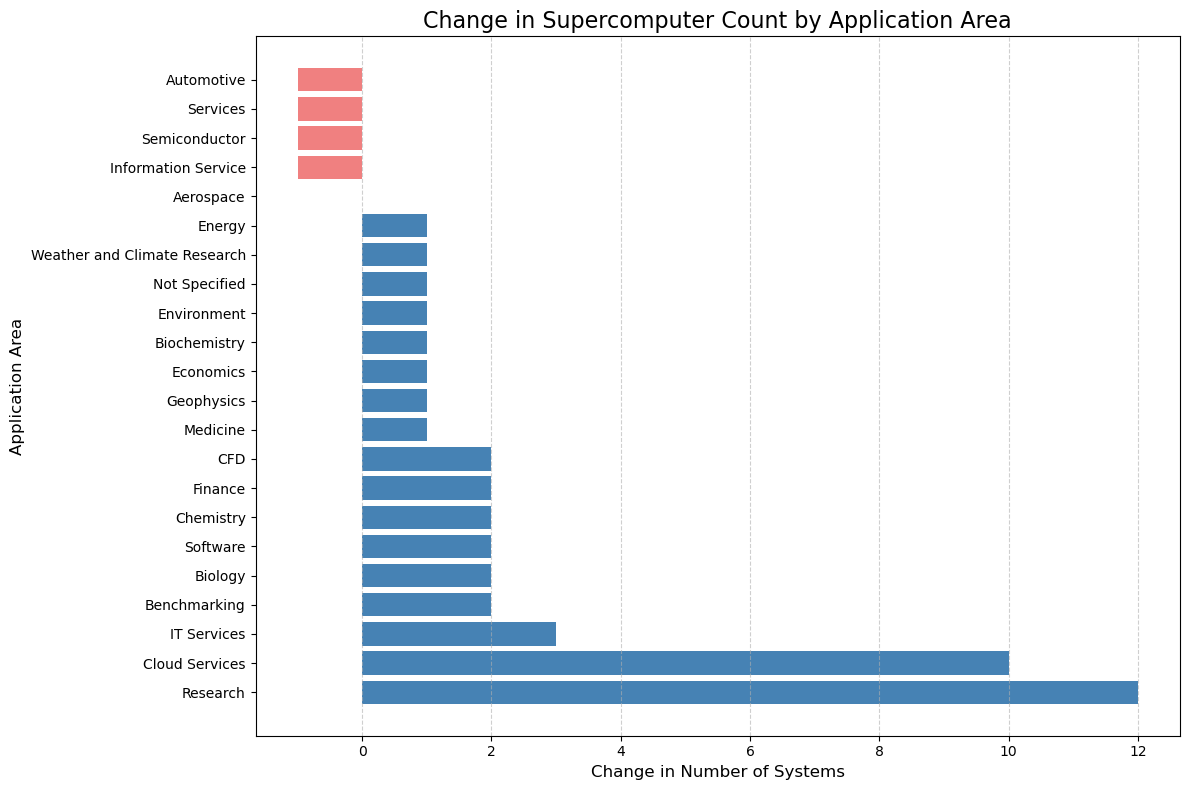

In [5]:
# --- Analysis for Application Areas ---
print("\n" + "="*50)
print("Analyzing Application Area Data")
print("="*50 + "\n")


for df in [df_app_june_2025, df_app_june_2020]:
    for col in ['Count', 'Rmax (GFlops)']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)


merged_app = pd.merge(df_app_june_2025, df_app_june_2020, on='Application Area', how='outer', suffixes=('_2025', '_2020')).fillna(0)
merged_app['Count_Change'] = merged_app['Count_2025'] - merged_app['Count_2020']
merged_app['Rmax_Change'] = merged_app['Rmax (GFlops)_2025'] - merged_app['Rmax (GFlops)_2020']

# Plot 3: Change in Application Area Count
plot_app_count = merged_app.sort_values(by='Count_Change', ascending=False)
plt.figure(figsize=(12, 8))
plt.barh(plot_app_count['Application Area'], plot_app_count['Count_Change'], color=['steelblue' if c > 0 else 'lightcoral' for c in plot_app_count['Count_Change']])
plt.title('Change in Supercomputer Count by Application Area', fontsize=16)
plt.xlabel('Change in Number of Systems', fontsize=12)
plt.ylabel('Application Area', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


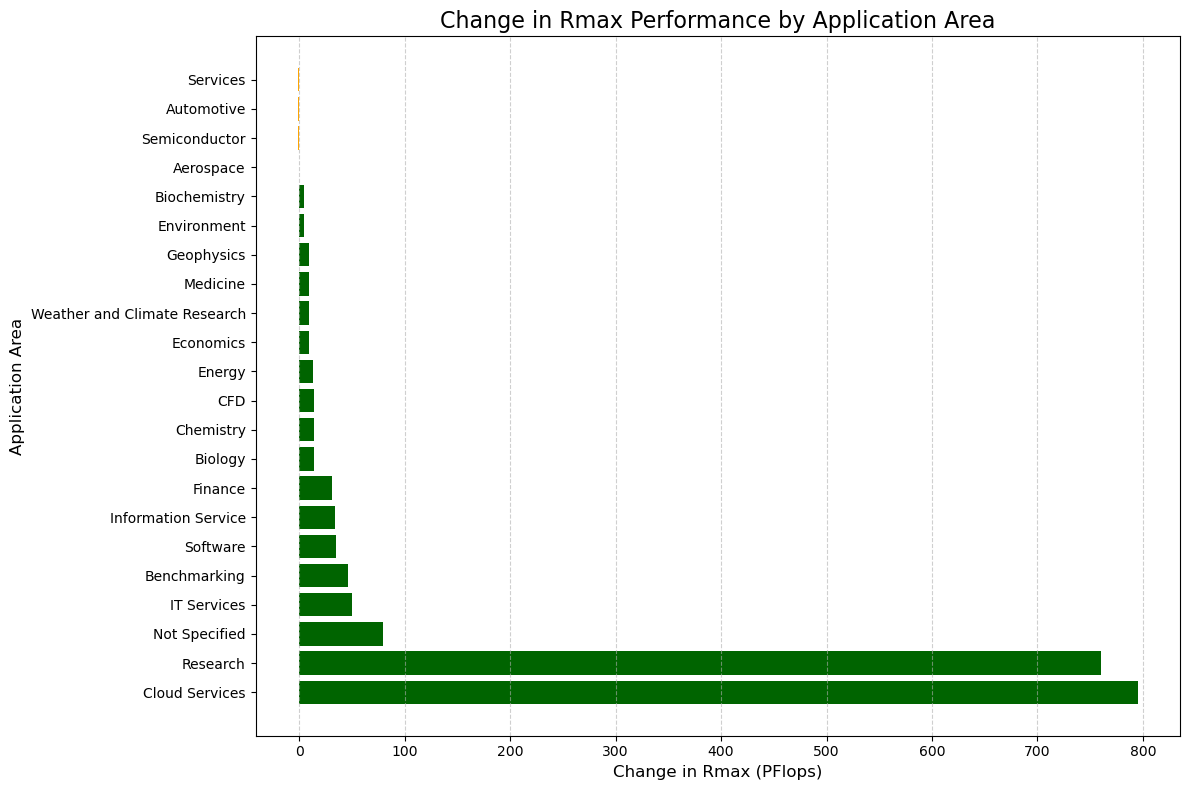

In [6]:
# Plot 4: Change in Application Area Rmax Performance
plot_app_rmax = merged_app.sort_values(by='Rmax_Change', ascending=False)
plt.figure(figsize=(12, 8))
plt.barh(plot_app_rmax['Application Area'], plot_app_rmax['Rmax_Change'] / 1e6, color=['darkgreen' if c > 0 else 'orange' for c in plot_app_rmax['Rmax_Change']])
plt.title('Change in Rmax Performance by Application Area', fontsize=16)
plt.xlabel('Change in Rmax (PFlops)', fontsize=12)
plt.ylabel('Application Area', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Analyzing Segments Data



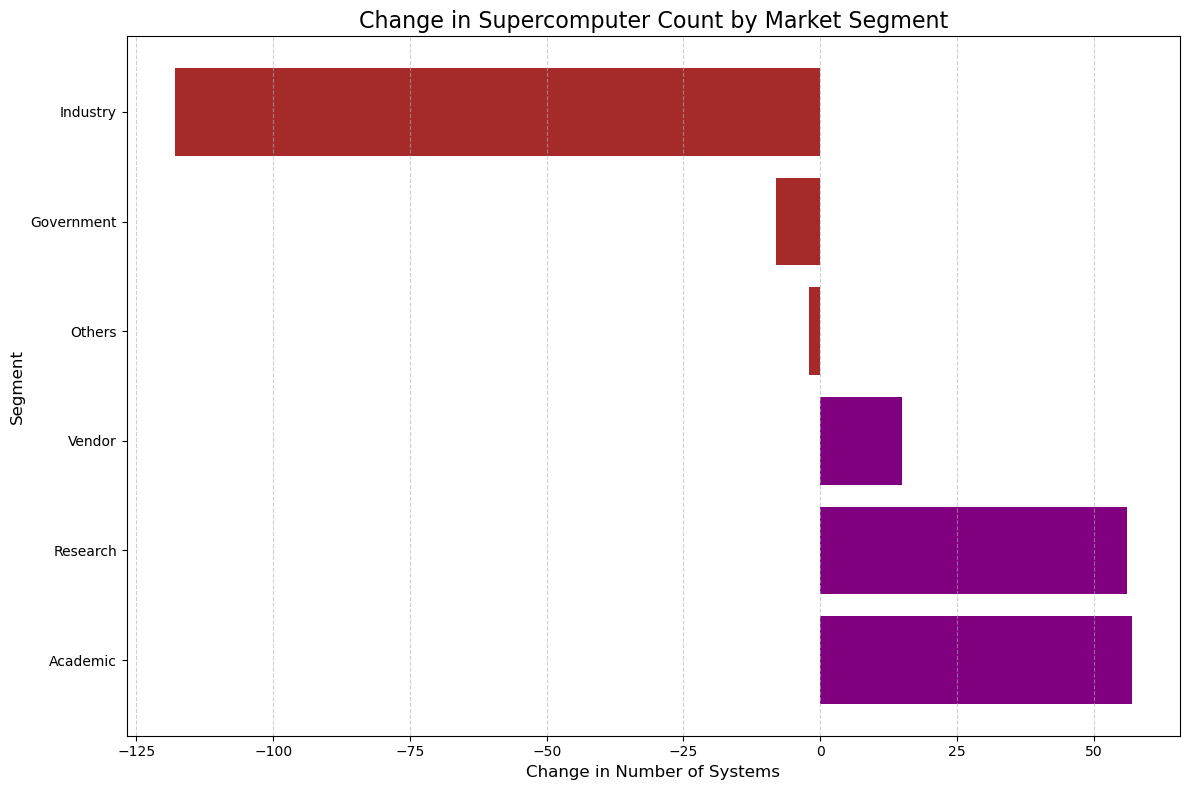

In [7]:
# --- Analysis for Segments ---
print("\n" + "="*50)
print("Analyzing Segments Data")
print("="*50 + "\n")


for df in [df_seg_june_2025, df_seg_june_2020]:
    for col in ['Count', 'Rmax (GFlops)']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)


merged_seg = pd.merge(df_seg_june_2025, df_seg_june_2020, on='Segment', how='outer', suffixes=('_2025', '_2020')).fillna(0)
merged_seg['Count_Change'] = merged_seg['Count_2025'] - merged_seg['Count_2020']
merged_seg['Rmax_Change'] = merged_seg['Rmax (GFlops)_2025'] - merged_seg['Rmax (GFlops)_2020']

# Plot 5: Change in Segments Count
plot_seg_count = merged_seg.sort_values(by='Count_Change', ascending=False)
plt.figure(figsize=(12, 8))
plt.barh(plot_seg_count['Segment'], plot_seg_count['Count_Change'], color=['purple' if c > 0 else 'brown' for c in plot_seg_count['Count_Change']])
plt.title('Change in Supercomputer Count by Market Segment', fontsize=16)
plt.xlabel('Change in Number of Systems', fontsize=12)
plt.ylabel('Segment', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

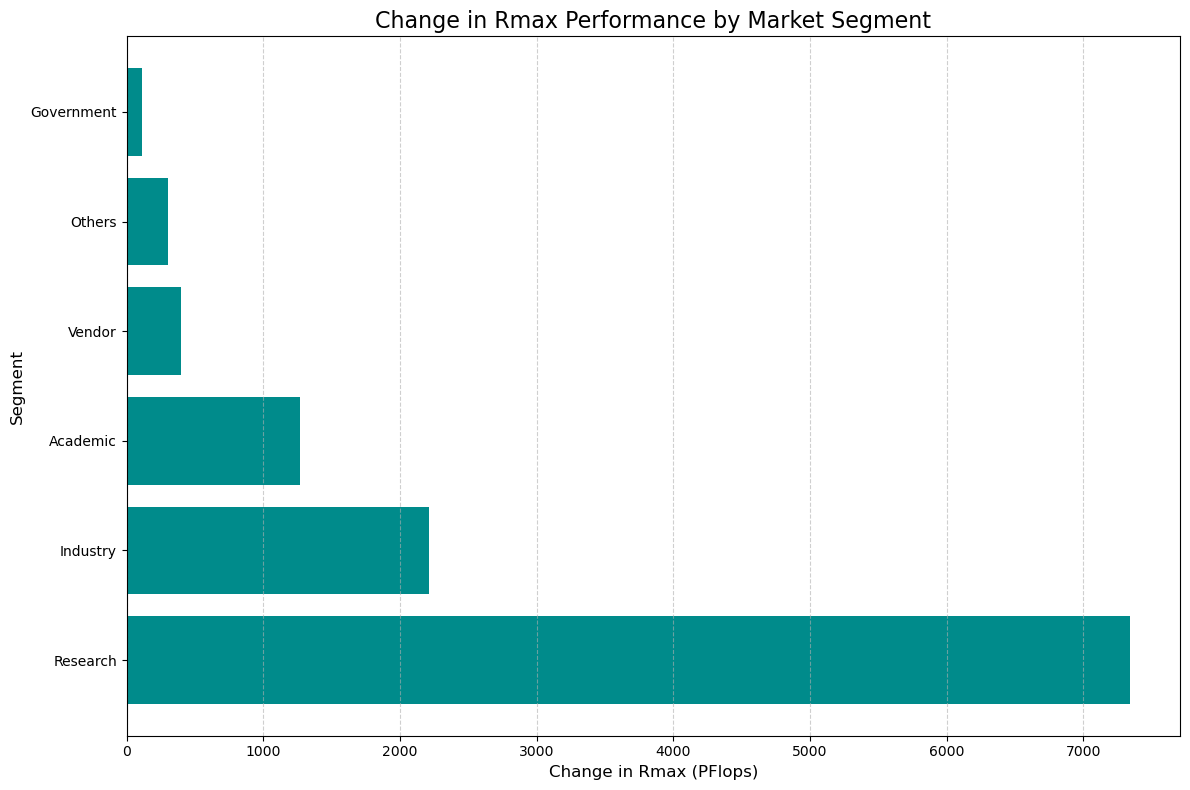

In [8]:
# Plot 6: Change in Segments Rmax Performance
plot_seg_rmax = merged_seg.sort_values(by='Rmax_Change', ascending=False)
plt.figure(figsize=(12, 8))
plt.barh(plot_seg_rmax['Segment'], plot_seg_rmax['Rmax_Change'] / 1e6, color=['darkcyan' if c > 0 else 'darkorange' for c in plot_seg_rmax['Rmax_Change']])
plt.title('Change in Rmax Performance by Market Segment', fontsize=16)
plt.xlabel('Change in Rmax (PFlops)', fontsize=12)
plt.ylabel('Segment', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [96]:
merged_cr

,Rank_2025,Country,Count_2025,System Share (%)_2025,Rmax (GFlops)_2025,Rpeak (GFlops)_2025,Cores_2025,Rank_2020,Count_2020,System Share (%)_2020,Rmax (GFlops)_2020,Rpeak (GFlops)_2020,Cores_2020,Count_Change
0,1,United States,175.0,35,6698604970,10642950168,"58,129,200",2,113.0,2025-06-22 00:00:00,621655590,884317444,"15,221,208",62.0
1,2,China,47.0,2025-04-09 00:00:00,281269604,471807345,"18,920,568",1,226.0,45.2,565553102,1186992367,"31,277,940",-179.0
2,3,Germany,41.0,2025-02-08 00:00:00,1185266660,1519298880,"8,943,756",5,16.0,2025-02-03 00:00:00,68713720,101130880,"1,749,814",25.0
3,4,Japan,39.0,2025-08-07 00:00:00,1229009840,1631301398,"12,787,024",3,29.0,2025-08-05 00:00:00,527607512,691558660,"11,153,228",10.0
4,5,France,25.0,5,327543500,508630042,"4,676,480",4,19.0,2025-08-03 00:00:00,79878820,121553694,"2,428,600",6.0
5,6,Italy,17.0,2025-04-03 00:00:00,874883920,1128393618,"7,730,480",10,7.0,2025-04-01 00:00:00,87188790,128918596,"1,811,568",10.0
6,7,South Korea,15.0,3,323114900,442276740,"2,799,412",13,3.0,0.6,18720660,31496620,709.22,12.0
7,8,Canada,13.0,2025-06-02 00:00:00,78990060,138729945,"1,051,472",8,13.0,2025-06-02 00:00:00,27926060,50348729,767.296,0.0
8,9,United Kingdom,13.0,2025-06-02 00:00:00,394527564,540015334,"3,152,784",9,10.0,2,30950142,37703042,"1,168,368",3.0
9,10,Brazil,9.0,2025-08-01 00:00:00,67911650,122168142,874.72,11,4.0,0.8,10991000,19270566,214.04,5.0
